In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Task 1.2: PySpark

# Step 1: Install PySpark

In [ ]:
!pip install pyspark findspark

# Step 2: Initialize Spark

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Arabic_AI_Text_Detection") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark is ready!")
print(f"Spark Version: {spark.version}")
print(f"Python Version: {spark.sparkContext.pythonVer}")

✅ Spark is ready!
Spark Version: 4.0.2
Python Version: 3.12


# Task 1.3: Download + Ingest Data

# Step 1: Install and Load Dataset

In [ ]:
!pip install -q datasets

from datasets import load_dataset

dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("="*60)
print("Dataset Loaded Successfully!")
print("="*60)
print(dataset)
print("\n" + "="*60)
print("Dataset Statistics:")
print("="*60)

for split_name in dataset.keys():
    print(f"  • {split_name}: {len(dataset[split_name])} samples")
    print(f"    Columns: {list(dataset[split_name].column_names)}")

print("\n" + "="*60)
print(f"Total samples across all splits: {sum(len(dataset[split]) for split in dataset.keys())}")
print("="*60)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/by_polishing-00000-of-00001.parquet:   0%|          | 0.00/8.49M [00:00<?, ?B/s]

data/from_title-00000-of-00001.parquet:   0%|          | 0.00/6.90M [00:00<?, ?B/s]

data/from_title_and_content-00000-of-000(…):   0%|          | 0.00/7.01M [00:00<?, ?B/s]

Generating by_polishing split:   0%|          | 0/2851 [00:00<?, ? examples/s]

Generating from_title split:   0%|          | 0/2963 [00:00<?, ? examples/s]

Generating from_title_and_content split:   0%|          | 0/2574 [00:00<?, ? examples/s]

Dataset Loaded Successfully!
DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})

Dataset Statistics:
  • by_polishing: 2851 samples
    Columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  • from_title: 2963 samples
    Columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstra

# Step 2: Process and Convert All Datasets

In [ ]:
for name in ["by_polishing", "from_title", "from_title_and_content"]:
    print(f"\n Processing: {name}")
    df = dataset[name].to_pandas()
    print("Pandas Preview:")
    print(df.head(2))
    spark_df = spark.createDataFrame(df)
    print("Spark Preview:")
    spark_df.show(2)
    path = f"data/raw/{name}.parquet"
    spark_df.write.mode("overwrite").parquet(path)
    print(f"Saved to: {path}")


 Processing: by_polishing
Pandas Preview:
                                   original_abstract  \
0  كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...   
1  يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...   

                            allam_generated_abstract  \
0  يتناول هذا البحث موضوع التعليم بين النساء الأن...   
1  يتناول هذا البحث دراسة انهيار دولة الموحدين من...   

                             jais_generated_abstract  \
0  تدرس هذه الدراسة دور المرأة في التعليم في الأن...   
1  كان العامل الثقافي من بين الأسباب الرئيسية الت...   

                            llama_generated_abstract  \
0  يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...   
1  يعد العامل الثقافي أحد أبرز الأسباب التي يعزى ...   

                           openai_generated_abstract  
0  صور نظام التعليم عند المرأة الأندلسية تستند إل...  
1  انهيار دولة الموحدين يعود بشكل كبير للعوامل ال...  
Spark Preview:
+--------------------+------------------------+-----------------------+------------------------+-----

# Step 3: Verify Stored Data for All Datasets


In [ ]:
# Task 1.3: Download + Ingest Data

# Step 3: Verify Stored Data for All Datasets

print("="*70)
print(" Verifying Saved Parquet Files")
print("="*70)

for name in ["by_polishing", "from_title", "from_title_and_content"]:
    print(f"\n{'='*70}")
    print(f" Verifying: {name}")
    print("="*70)

    path = f"data/raw/{name}.parquet"

    test_df = spark.read.parquet(path)

    row_count = test_df.count()
    col_count = len(test_df.columns)

    print(f"Successfully loaded from: {path}")
    print(f"Rows: {row_count} | Columns: {col_count}")
    print(f"Columns: {test_df.columns}")

    print(f"\n Sample (5 rows, text truncated to 60 chars):")
    test_df.show(5, truncate=60)

print("\n" + "="*70)
print("All Parquet files verified successfully!")
print("="*70)

 Verifying Saved Parquet Files

 Verifying: by_polishing
Successfully loaded from: data/raw/by_polishing.parquet
Rows: 2851 | Columns: 5
Columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']

 Sample (5 rows, text truncated to 60 chars):
+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------------------------+
|                                           original_abstract|                                    allam_generated_abstract|                                     jais_generated_abstract|                                    llama_generated_abstract|                                   openai_generated_abstract|
+----------------------------------------------------------

# Task 1.4: Exploratory Data Analysis (EDA)

# Step 1: Load Data from Parquet



In [ ]:
from pyspark.sql import functions as F

print("="*70)
print(" Loading and Combining Dataset Splits")
print("="*70)

dfs = []

for name in ["by_polishing", "from_title", "from_title_and_content"]:
    path = f"data/raw/{name}.parquet"

    df = spark.read.parquet(path)

    df = df.withColumn("source", F.lit(name))

    dfs.append(df)
    print(f" Loaded {df.count()} rows from {name}")

full_df = dfs[0]
for d in dfs[1:]:
    full_df = full_df.unionByName(d)

print("\n" + "="*70)
print(f" Combined DataFrame: {full_df.count()} total rows")
print("="*70)

print("\n Sample (5 rows):")
full_df.show(5, truncate=50)

print("\n chema:")
full_df.printSchema()

print("Total Records:", full_df.count())

 Loading and Combining Dataset Splits
 Loaded 2851 rows from by_polishing
 Loaded 2963 rows from from_title
 Loaded 2574 rows from from_title_and_content

 Combined DataFrame: 8388 total rows

 Sample (5 rows):
+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+------------+
|                                 original_abstract|                          allam_generated_abstract|                           jais_generated_abstract|                          llama_generated_abstract|                         openai_generated_abstract|      source|
+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------------+--------------------------------------------

In [ ]:
from pyspark.sql.functions import col, sum

full_df.select(
        [sum(col(c).isNull().cast("int")).alias(c) for c in full_df.columns]
        ).show()

+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+
|original_abstract|allam_generated_abstract|jais_generated_abstract|llama_generated_abstract|openai_generated_abstract|source|
+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+
|                0|                       0|                      0|                       0|                        0|     0|
+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+




# Step 5: Create Classification Dataset


In [ ]:
from pyspark.sql.functions import col, lit

print("="*70)
print("Creating Binary Classification Dataset")
print("="*70)

classification_dfs = []

human = full_df.select(
    col("original_abstract").alias("text"),
    lit(0).alias("label")
)
classification_dfs.append(human)

ai_columns = [
    "allam_generated_abstract",
    "jais_generated_abstract",
    "llama_generated_abstract",
    "openai_generated_abstract"
]

for col_name in ai_columns:
    ai_df = full_df.select(
        col(col_name).alias("text"),
        lit(1).alias("label")
    )
    classification_dfs.append(ai_df)

from functools import reduce
classification_df = reduce(lambda a, b: a.union(b), classification_dfs)

total_rows = classification_df.count()
print(f"\nTotal rows: {total_rows}")

print("\nLabel distribution:")
classification_df.groupBy("label").count().orderBy("label").show()

print("\nSample (10 rows):")
classification_df.show(10, truncate=50)

output_path = "data/processed/classification_dataset.parquet"
classification_df.write.mode("overwrite").parquet(output_path)
print(f"\nSaved to: {output_path}")

print("="*70)

Creating Binary Classification Dataset

Total rows: 41940

Label distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0| 8388|
|    1|33552|
+-----+-----+


Sample (10 rows):
+--------------------------------------------------+-----+
|                                              text|label|
+--------------------------------------------------+-----+
|تهدف هذه الدراسة إلى تسليط الضوء على أسس القياس...|    0|
|تهدف هذه الدراسة إلى تحليل مدى توفر نظام لضمان ...|    0|
|تهدف هذه الدراسة على تسليط الضوء على الأهمية ال...|    0|
|يعتبر الشمول المالي من المواضيع الحديثة التي بر...|    0|
|يعتبر صندوق المشاركين آلية من أهم الآليات التي ...|    0|
|تهدف الدراسة إلى إبراز مدى إلتزام البنوك الجزائ...|    0|
|هدف من هذه الدراسة هو التعرف على الدور الذي تلع...|    0|
|يهدف هذا البحث إلى التعرف على واقع السياحة البي...|    0|
|هدفت الدراسة إلي التعرف علي أهمية الثقافة الأمن...|    0|
|هتمت هذه الدراسة بعرض نشاط تطوير المنتجات في ال...|    0|
+-------------------------------------------------

# ----------------------------------
#Phase 2


# Task 2.1: Arabic Text Preprocessing

# Step 1: Normalization


In [ ]:
import re
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def normalize(text):
    if text is None:
        return ""

    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    return text

normalize_udf = udf(normalize, StringType())

df_norm = classification_df.withColumn(
    "normalized_text",
    normalize_udf(col("text"))
)


# Step 2: Remove Diacritics


In [ ]:
def remove_diacritics(text):
    if text is None:
        return ""

    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    return text

diacritic_udf = udf(remove_diacritics, StringType())

df_no_diac = df_norm.withColumn(
    "clean_text",
    diacritic_udf(col("normalized_text"))
)


# Step 3: Stopwords Removal


In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from pyspark.ml.feature import Tokenizer, StopWordsRemover

arabic_stopwords = stopwords.words('arabic')


tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
df_tokens = tokenizer.transform(df_no_diac)


remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=arabic_stopwords
)

df_stop = remover.transform(df_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Step 4: Stemming


In [ ]:
print("\nStep 4: Arabic Stemming")
print("-"*70)

from nltk.stem.isri import ISRIStemmer
from pyspark.sql.types import ArrayType

stemmer = ISRIStemmer()

def stem_arabic(words):
    """
    Apply ISRI Arabic stemmer to extract word roots.
    ISRI stemmer handles Arabic morphology (prefixes, suffixes, infixes).
    """
    if words is None:
        return []
    return [stemmer.stem(w) for w in words]

stem_udf = udf(stem_arabic, ArrayType(StringType()))

df_stem = df_stop.withColumn(
    "stemmed_words",
    stem_udf(col("filtered_words"))
)

print(f"Stemmed {df_stem.count()} rows")

print("\nSample (filtered_words → stemmed_words):")
df_stem.select("filtered_words", "stemmed_words").show(2, truncate=60)

print("-"*70)


Step 4: Arabic Stemming
----------------------------------------------------------------------
Stemmed 41940 rows

Sample (filtered_words → stemmed_words):
+------------------------------------------------------------+------------------------------------------------------------+
|                                              filtered_words|                                               stemmed_words|
+------------------------------------------------------------+------------------------------------------------------------+
|[تهدف, الدراسه, الي, تسليط, الضوء, علي, اسس, القياس, المح...|[هدف, درس, الي, سلط, ضوء, علي, اسس, قيس, حسب, تبن, نظم, ح...|
|[تهدف, الدراسه, الي, تحليل, مدي, توفر, نظام, لضمان, الودا...|[هدف, درس, الي, حلل, مدي, وفر, نظم, لضم, ديع, صرف, لدي, ص...|
+------------------------------------------------------------+------------------------------------------------------------+
only showing top 2 rows
----------------------------------------------------------------------



# Step 5: Reconstruct Clean Text


In [ ]:
from pyspark.sql.functions import concat_ws

df_final = df_stem.withColumn(
    "abstract_clean",
    concat_ws(" ", col("stemmed_words"))
)

# Task 2.2: Store Processed Data

# Step 1: Data Store


In [ ]:
print("\n" + "="*70)
print("Task 2.2: Store Processed Data in Parquet")
print("="*70)

df_preprocessed = df_final.select(
    "text",
    "abstract_clean",
    "label"
)

print(f"\nSelected {len(df_preprocessed.columns)} columns for storage:")
print(f"  - text (original)")
print(f"  - abstract_clean (preprocessed)")
print(f"  - label (classification target)")

output_path = "data/processed/cleaned_data.parquet"
df_preprocessed.write.mode("overwrite").parquet(output_path)

print(f"\nSaved {df_preprocessed.count()} rows to: {output_path}")

print("\nVerifying saved data:")
test_df = spark.read.parquet(output_path)
test_df.printSchema()
test_df.show(3, truncate=50)

print("\nData stored successfully!")
print("="*70)


Task 2.2: Store Processed Data in Parquet

Selected 3 columns for storage:
  - text (original)
  - abstract_clean (preprocessed)
  - label (classification target)

Saved 41940 rows to: data/processed/cleaned_data.parquet

Verifying saved data:
root
 |-- text: string (nullable = true)
 |-- abstract_clean: string (nullable = true)
 |-- label: integer (nullable = true)

+--------------------------------------------------+--------------------------------------------------+-----+
|                                              text|                                    abstract_clean|label|
+--------------------------------------------------+--------------------------------------------------+-----+
|تهدف هذه الدراسة إلى تحليل نقدي لنماذج القياس ا...|هدف درس الي حلل نقد اذج قيس حسب ضمن نظم حسب الي...|    1|
|تهدف هذه الدراسة إلى تقييم فعالية نظام ضمان الو...|هدف درس الي قيم فعل نظم ضمن ديع صرف سلم ارد خلل...|    1|
|تهدف هذه الدراسة إلى تحليل الدور المتنامي للشرا...|هدف درس الي حلل دور تنم شرك

# Task 2.3: Exploratory Data Analysis (EDA)

# Step 1: Word Cloud Visualization




Installing Arabic font...

Sampling data for word clouds...
Human text sample: 2189048 characters
AI text sample: 1922402 characters

Generating word clouds...


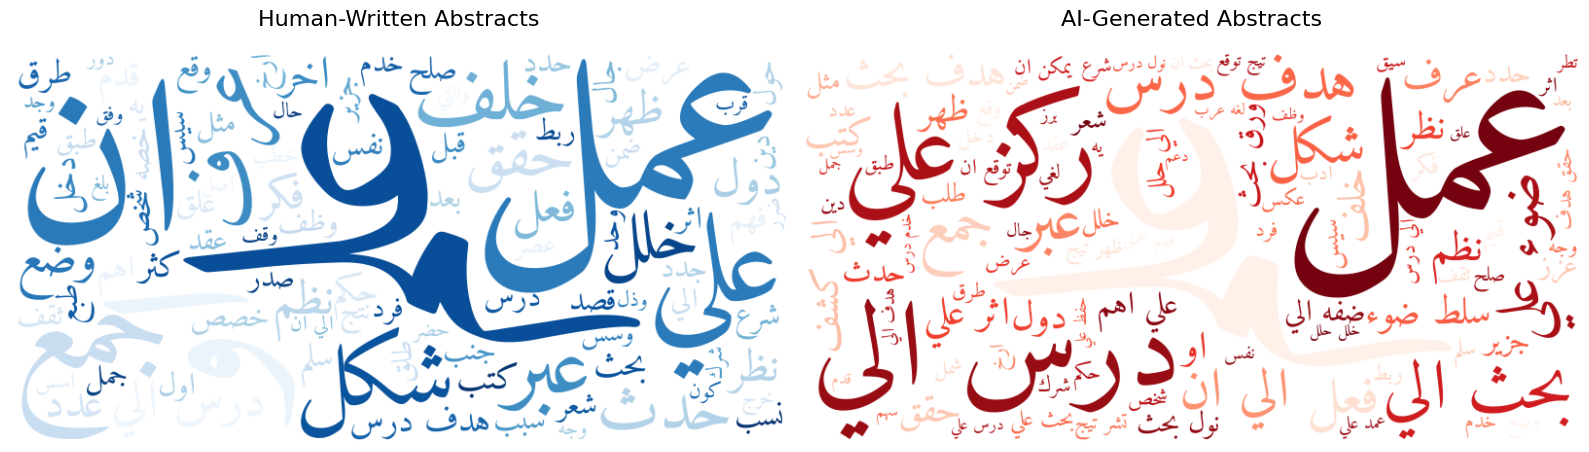

In [ ]:
print("\nInstalling Arabic font...")
!apt-get install -y fonts-hosny-amiri > /dev/null 2>&1

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pyspark.sql.functions import rand
import os

print("\nSampling data for word clouds...")

human_sample = df_final.filter(col("label") == 0) \
    .orderBy(rand()) \
    .limit(5000) \
    .select("abstract_clean") \
    .rdd.map(lambda r: r[0]).collect()

ai_sample = df_final.filter(col("label") == 1) \
    .orderBy(rand()) \
    .limit(5000) \
    .select("abstract_clean") \
    .rdd.map(lambda r: r[0]).collect()

human_text = " ".join(human_sample)
ai_text = " ".join(ai_sample)

print(f"Human text sample: {len(human_text)} characters")
print(f"AI text sample: {len(ai_text)} characters")

print("\nGenerating word clouds...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_human = WordCloud(
    font_path="/usr/share/fonts/truetype/hosny-amiri/Amiri-Regular.ttf",
    background_color="white",
    width=800,
    height=400,
    max_words=100,
    colormap="Blues"
).generate(human_text)

axes[0].imshow(wc_human, interpolation='bilinear')
axes[0].set_title("Human-Written Abstracts", fontsize=16, pad=20)
axes[0].axis("off")

wc_ai = WordCloud(
    font_path="/usr/share/fonts/truetype/hosny-amiri/Amiri-Regular.ttf",
    background_color="white",
    width=800,
    height=400,
    max_words=100,
    colormap="Reds"
).generate(ai_text)

axes[1].imshow(wc_ai, interpolation='bilinear')
axes[1].set_title("AI-Generated Abstracts", fontsize=16, pad=20)
axes[1].axis("off")

plt.tight_layout()



print("="*70)

# Step 2: N-Gram Frequency

In [ ]:
from pyspark.ml.feature import NGram

ngram = NGram(n=2, inputCol="words", outputCol="bigrams")

df_ngram = ngram.transform(df_final)

from pyspark.sql.functions import explode

bigrams = df_ngram.select(explode("bigrams").alias("bigram"))

bigram_counts = bigrams.groupBy("bigram").count().orderBy("count", ascending=False)

bigram_counts.limit(10).toPandas()

,bigram,count
0,من خلال,20415
1,هذه الدراسه,15834
2,الدراسه الي,15551
3,هذا البحث,10730
4,البحث الي,10539
5,الضوء علي,9864
6,التركيز علي,9225
7,مع التركيز,8354
8,الي ان,8222
9,تهدف هذه,7633


# ----------------------------------
#Phase 3

# Task 3.1: Features

In [ ]:
# Task 3.1: Traditional Features - Stylometric Features

print("\n" + "="*70)
print("PHASE 3: Feature Engineering - Stylometric Features")
print("="*70)

from pyspark.sql.functions import udf, col, length, size, split
from pyspark.sql.types import IntegerType, FloatType
import re

# Feature 1: Brunet's W - Vocabulary richness measure

def brunets_w(text):
    if text is None or text.strip() == "":
        return 0.0

    words = text.split()
    N = len(words)

    if N == 0:
        return 0.0

    V = len(set(words))

    if V == 0 or N == 1:
        return 0.0

    a = 0.165
    W = N ** (V ** -a)

    return float(W)

brunets_w_udf = udf(brunets_w, FloatType())

df_features = df_preprocessed.withColumn(
    "brunets_w",
    brunets_w_udf(col("abstract_clean"))
)

print("\nFeature 1: Brunet's W extracted")

# Feature 2: Named Entity Density using Arabic NER patterns

def arabic_ner_count(text):
    if text is None or text.strip() == "":
        return 0

    # Common Arabic NER patterns
    patterns = [
        r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*',  # Latin names
        r'د\.\s*\w+',  # Dr. titles
        r'أ\.\s*د\.\s*\w+',  # Prof. titles
        r'\b(محمد|أحمد|علي|فاطمة|عائشة|خديجة)\b',  # Common names
        r'\b(مصر|السعودية|الأردن|لبنان|سوريا|العراق)\b',  # Countries
        r'\b(القاهرة|الرياض|عمان|بيروت|دمشق|بغداد)\b',  # Cities
    ]

    count = 0
    for pattern in patterns:
        matches = re.findall(pattern, text)
        count += len(matches)

    return count

ner_count_udf = udf(arabic_ner_count, IntegerType())

df_features = df_features.withColumn(
    "named_entity_count",
    ner_count_udf(col("text"))
)

print("Feature 2: Named Entity Count extracted")

# Feature 3: Morphological Complexity - Average word length

df_features = df_features.withColumn(
    "avg_word_length",
    length(col("abstract_clean")) / size(split(col("abstract_clean"), " "))
)

print("Feature 3: Average Word Length extracted")

# Feature 4: Lexical Diversity (Type-Token Ratio per document)

def lexical_diversity(text):
    if text is None or text.strip() == "":
        return 0.0

    words = text.split()

    if len(words) == 0:
        return 0.0

    unique_words = len(set(words))
    total_words = len(words)

    ttr = unique_words / total_words

    return float(ttr)

lexical_diversity_udf = udf(lexical_diversity, FloatType())

df_features = df_features.withColumn(
    "lexical_diversity",
    lexical_diversity_udf(col("abstract_clean"))
)

print("Feature 4: Lexical Diversity extracted")

print("\nAll 4 stylometric features extracted successfully")
print(f"Total rows: {df_features.count()}")

print("\nSample features:")
df_features.select(
    "label",
    "brunets_w",
    "named_entity_count",
    "avg_word_length",
    "lexical_diversity"
).show(5)

print("\nFeature Statistics:")
df_features.select(
    "brunets_w",
    "named_entity_count",
    "avg_word_length",
    "lexical_diversity"
).describe().show()

print("="*70)


PHASE 3: Feature Engineering - Stylometric Features

Feature 1: Brunet's W extracted
Feature 2: Named Entity Count extracted
Feature 3: Average Word Length extracted
Feature 4: Lexical Diversity extracted

All 4 stylometric features extracted successfully
Total rows: 41940

Sample features:
+-----+---------+------------------+-----------------+-----------------+
|label|brunets_w|named_entity_count|  avg_word_length|lexical_diversity|
+-----+---------+------------------+-----------------+-----------------+
|    0| 8.771713|                 0|4.645161290322581|        0.7903226|
|    0|  9.86684|                 0|4.186813186813187|        0.6703297|
|    0|10.103794|                 1|4.385964912280702|        0.6754386|
|    0| 9.415631|                 0|4.243589743589744|       0.71794873|
|    0| 8.510697|                 0|4.573529411764706|       0.89705884|
+-----+---------+------------------+-----------------+-----------------+
only showing top 5 rows

Feature Statistics:
+----

In [ ]:
# Task 3.1: Traditional Features - Stylometric Features

print("\n" + "="*70)
print("PHASE 3: Feature Engineering - Stylometric Features")
print("="*70)

from pyspark.sql.functions import udf, col
from pyspark.sql.types import IntegerType, FloatType
import re

# Feature 1: Brunet's W - Vocabulary richness

def brunets_w(text):
    try:
        if text is None or text.strip() == "":
            return 0.0

        words = text.split()
        N = len(words)

        if N == 0:
            return 0.0

        V = len(set(words))

        if V == 0 or N == 1:
            return 0.0

        a = 0.165
        W = N ** (V ** -a)

        return float(W)
    except Exception as e:
        return 0.0

brunets_w_udf = udf(brunets_w, FloatType())

# Feature 2: Named Entity Count

def count_named_entities(text):
    try:
        if text is None or text.strip() == "":
            return 0

        patterns = [
            r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*',
            r'د\.\s*\w+',
            r'أ\.\s*د\.\s*\w+',
            r'\b(محمد|أحمد|علي|فاطمة|عائشة|خديجة|يوسف|إبراهيم|عمر|عثمان)\b',
            r'\b(مصر|السعودية|الأردن|لبنان|سوريا|العراق|فلسطين|المغرب|الجزائر|تونس)\b',
            r'\b(القاهرة|الرياض|جدة|عمان|بيروت|دمشق|بغداد|الدوحة|دبي|أبوظبي)\b',
        ]

        count = 0
        for pattern in patterns:
            matches = re.findall(pattern, text)
            count += len(matches)

        return int(count)
    except Exception as e:
        return 0

named_entities_udf = udf(count_named_entities, IntegerType())

# Feature 3: Lexical Diversity

def lexical_diversity(text):
    try:
        if text is None or text.strip() == "":
            return 0.0

        words = text.split()

        if len(words) == 0:
            return 0.0

        unique_words = len(set(words))
        total_words = len(words)

        ttr = unique_words / total_words

        return float(ttr)
    except Exception as e:
        return 0.0

lexical_diversity_udf = udf(lexical_diversity, FloatType())

# Feature 4: Average Word Length

def avg_word_length(text):
    try:
        if text is None or text.strip() == "":
            return 0.0

        words = text.split()

        if len(words) == 0:
            return 0.0

        total_length = sum(len(word) for word in words)
        avg_length = total_length / len(words)

        return float(avg_length)
    except Exception as e:
        return 0.0

avg_word_length_udf = udf(avg_word_length, FloatType())

# Step 3: Apply Features on Spark

print("\nApplying stylometric features...")

df_features = df_final.withColumn(
    "f_brunets_w",
    brunets_w_udf(col("abstract_clean"))
)

print("✓ Feature 1 applied: Brunet's W")

df_features = df_features.withColumn(
    "f_named_entities",
    named_entities_udf(col("text"))
)

print("✓ Feature 2 applied: Named Entities")

df_features = df_features.withColumn(
    "f_lexical_diversity",
    lexical_diversity_udf(col("abstract_clean"))
)

print("✓ Feature 3 applied: Lexical Diversity")

df_features = df_features.withColumn(
    "f_avg_word_length",
    avg_word_length_udf(col("abstract_clean"))
)

print("✓ Feature 4 applied: Average Word Length")

print("\nAll 4 stylometric features applied successfully")
print(f"Total rows: {df_features.count()}")

# Preview - without toPandas first to check if the data is valid

print("\nSample features (showing 5 rows):")
df_features.select(
    "label",
    "f_brunets_w",
    "f_named_entities",
    "f_lexical_diversity",
    "f_avg_word_length"
).show(5, truncate=False)

# Now convert to pandas if needed
print("\nConverting to Pandas for detailed view...")
sample_df = df_features.select(
    "label",
    "f_brunets_w",
    "f_named_entities",
    "f_lexical_diversity",
    "f_avg_word_length"
).limit(10).toPandas()

print(sample_df)

# Save
print("\nSaving features to parquet...")
df_features.write.mode("overwrite").parquet("data/features/stylometric_features.parquet")
print("✓ Saved to: data/features/stylometric_features.parquet")

print("="*70)


PHASE 3: Feature Engineering - Stylometric Features

Applying stylometric features...
✓ Feature 1 applied: Brunet's W
✓ Feature 2 applied: Named Entities
✓ Feature 3 applied: Lexical Diversity
✓ Feature 4 applied: Average Word Length

All 4 stylometric features applied successfully
Total rows: 41940

Sample features (showing 5 rows):
+-----+-----------+----------------+-------------------+-----------------+
|label|f_brunets_w|f_named_entities|f_lexical_diversity|f_avg_word_length|
+-----+-----------+----------------+-------------------+-----------------+
|0    |8.771713   |1               |0.7903226          |0.0              |
|0    |9.86684    |0               |0.6703297          |0.0              |
|0    |10.103794  |1               |0.6754386          |0.0              |
|0    |9.415631   |2               |0.71794873         |0.0              |
|0    |8.510697   |0               |0.89705884         |0.0              |
+-----+-----------+----------------+-------------------+-------

# Task 3.2: TF-IDF Feature Extraction

# Step 1: Tokenization

In [ ]:
print("\n" + "="*70)
print("PHASE 3: TF-IDF Feature Extraction")
print("="*70)

from pyspark.ml.feature import Tokenizer, HashingTF, IDF

print("\nStep 1: Tokenization...")

tokenizer = Tokenizer(
    inputCol="abstract_clean",
    outputCol="words_tfidf"
)

df_words = tokenizer.transform(df_features)

print(f"✓ Tokenization complete")
print(f"  Total documents: {df_words.count()}")

print("\nStep 2: Computing Term Frequency (TF)...")

hashingTF = HashingTF(
    inputCol="words_tfidf",
    outputCol="raw_features",
    numFeatures=10000
)

df_tf = hashingTF.transform(df_words)

print(f"✓ TF computed")
print(f"  Feature vector size: 10,000")

print("\nStep 3: Computing Inverse Document Frequency (IDF)...")

idf = IDF(
    inputCol="raw_features",
    outputCol="tfidf_features"
)

idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

print(f"✓ IDF computed")
print(f"  TF-IDF features ready")

print("\nSample TF-IDF vectors:")
df_tfidf.select("label", "tfidf_features").show(5, truncate=True)


print("\nSaving TF-IDF features...")
df_tfidf.write.mode("overwrite").parquet("data/features/tfidf_features.parquet")
print(" Saved to: data/features/tfidf_features.parquet")

print("\n" + "="*70)


PHASE 3: TF-IDF Feature Extraction

Step 1: Tokenization...
✓ Tokenization complete
  Total documents: 41940

Step 2: Computing Term Frequency (TF)...
✓ TF computed
  Feature vector size: 10,000

Step 3: Computing Inverse Document Frequency (IDF)...
✓ IDF computed
  TF-IDF features ready

Sample TF-IDF vectors:
+-----+--------------------+
|label|      tfidf_features|
+-----+--------------------+
|    0|(10000,[77,249,35...|
|    0|(10000,[51,77,103...|
|    0|(10000,[14,77,249...|
|    0|(10000,[77,103,15...|
|    0|(10000,[64,126,15...|
+-----+--------------------+
only showing top 5 rows

Saving TF-IDF features...
 Saved to: data/features/tfidf_features.parquet



# Task 3.2: TF-IDF Feature Extraction

In [ ]:


from pyspark.ml.feature import Tokenizer, CountVectorizer, IDF

print("\nStep 1: Tokenization...")

tokenizer = Tokenizer(
    inputCol="abstract_clean",
    outputCol="words_tfidf"
)

df_words = tokenizer.transform(df_features)

print(f"✓ Tokenization complete")
print(f"  Total documents: {df_words.count()}")

# Step 2: CountVectorizer (Term Frequency)

print("\nStep 2: Computing Term Frequency using CountVectorizer...")

vectorizer = CountVectorizer(
    inputCol="words_tfidf",
    outputCol="tf_features",
    vocabSize=10000,
    minDF=2.0
)

cv_model = vectorizer.fit(df_words)
df_tf = cv_model.transform(df_words)

print(f"✓ CountVectorizer fitted")
print(f"  Vocabulary size: {len(cv_model.vocabulary)}")
print(f"  Max features: 10,000")
print(f"  Min document frequency: 2")

# Extract vocabulary
vocabulary = cv_model.vocabulary
print(f"\nSample vocabulary (first 20 words):")
print(vocabulary[:20])

# Step 3: Inverse Document Frequency (IDF)

print("\nStep 3: Computing Inverse Document Frequency (IDF)...")

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

print(f"✓ IDF computed")
print(f"  TF-IDF features ready")

# Preview

print("\nSample TF-IDF vectors:")
df_tfidf.select("label", "tfidf_features").show(5, truncate=True)

# Statistics

print("\nFeature statistics:")
print(f"  Total documents: {df_tfidf.count()}")
print(f"  Feature vector dimension: {len(cv_model.vocabulary)}")

# Save

print("\nSaving TF-IDF features and model...")
df_tfidf.write.mode("overwrite").parquet("data/features/tfidf_features.parquet")
cv_model.save("models/count_vectorizer_model")
idf_model.save("models/idf_model")





Step 1: Tokenization...
✓ Tokenization complete
  Total documents: 41940

Step 2: Computing Term Frequency using CountVectorizer...
✓ CountVectorizer fitted
  Vocabulary size: 10000
  Max features: 10,000
  Min document frequency: 2

Sample vocabulary (first 20 words):
['علي', 'الي', 'درس', 'بحث', 'علم', 'ان', 'هدف', 'حلل', 'جمع', 'عمل', 'خلل', 'اثر', 'خدم', 'حقق', 'شكل', 'فهم', 'عزز', 'ركز', 'فعل', 'قدم']

Step 3: Computing Inverse Document Frequency (IDF)...
✓ IDF computed
  TF-IDF features ready

Sample TF-IDF vectors:
+-----+--------------------+
|label|      tfidf_features|
+-----+--------------------+
|    0|(10000,[0,1,2,5,6...|
|    0|(10000,[0,1,2,6,7...|
|    0|(10000,[0,1,2,5,6...|
|    0|(10000,[0,1,2,3,4...|
|    0|(10000,[0,1,2,3,9...|
+-----+--------------------+
only showing top 5 rows

Feature statistics:
  Total documents: 41940
  Feature vector dimension: 10000

Saving TF-IDF features and model...


# IDF



In [ ]:
from pyspark.ml.feature import IDF

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

df_tfidf.limit(10).toPandas()

,text,label,normalized_text,clean_text,words,filtered_words,stemmed_words,abstract_clean,f_brunets_w,f_named_entities,f_lexical_diversity,f_avg_word_length,words_tfidf,tf_features,tfidf_features
0,تهدف هذه الدراسة إلى تسليط الضوء على أسس القيا...,0,تهدف هذه الدراسه الي تسليط الضوء علي اسس القيا...,تهدف هذه الدراسه الي تسليط الضوء علي اسس القيا...,"[تهدف, هذه, الدراسه, الي, تسليط, الضوء, علي, ا...","[تهدف, الدراسه, الي, تسليط, الضوء, علي, اسس, ا...","[هدف, درس, الي, سلط, ضوء, علي, اسس, قيس, حسب, ...",هدف درس الي سلط ضوء علي اسس قيس حسب تبن نظم حس...,8.771713,1,0.790323,0.0,"[هدف, درس, الي, سلط, ضوء, علي, اسس, قيس, حسب, ...","(1.0, 6.0, 2.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","(0.1122163121632009, 0.9830037888310675, 0.679..."
1,تهدف هذه الدراسة إلى تحليل مدى توفر نظام لضمان...,0,تهدف هذه الدراسه الي تحليل مدي توفر نظام لضمان...,تهدف هذه الدراسه الي تحليل مدي توفر نظام لضمان...,"[تهدف, هذه, الدراسه, الي, تحليل, مدي, توفر, نظ...","[تهدف, الدراسه, الي, تحليل, مدي, توفر, نظام, ل...","[هدف, درس, الي, حلل, مدي, وفر, نظم, لضم, ديع, ...",هدف درس الي حلل مدي وفر نظم لضم ديع صرف لدي صر...,9.866840,0,0.670330,0.0,"[هدف, درس, الي, حلل, مدي, وفر, نظم, لضم, ديع, ...","(1.0, 3.0, 3.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, ...","(0.1122163121632009, 0.49150189441553377, 1.01..."
2,تهدف هذه الدراسة على تسليط الضوء على الأهمية ا...,0,تهدف هذه الدراسه علي تسليط الضوء علي الاهميه ا...,تهدف هذه الدراسه علي تسليط الضوء علي الاهميه ا...,"[تهدف, هذه, الدراسه, علي, تسليط, الضوء, علي, ا...","[تهدف, الدراسه, علي, تسليط, الضوء, علي, الاهمي...","[هدف, درس, علي, سلط, ضوء, علي, اهم, زاد, شرك, ...",هدف درس علي سلط ضوء علي اهم زاد شرك قطع عام خا...,10.103794,1,0.675439,0.0,"[هدف, درس, علي, سلط, ضوء, علي, اهم, زاد, شرك, ...","(2.0, 2.0, 2.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","(0.2244326243264018, 0.32766792961035585, 0.67..."
3,يعتبر الشمول المالي من المواضيع الحديثة التي ب...,0,يعتبر الشمول المالي من المواضيع الحديثه التي ب...,يعتبر الشمول المالي من المواضيع الحديثه التي ب...,"[يعتبر, الشمول, المالي, من, المواضيع, الحديثه,...","[يعتبر, الشمول, المالي, المواضيع, الحديثه, برز...","[عبر, شمل, الي, مواضيع, حدث, برز, علي, سحه, دو...",عبر شمل الي مواضيع حدث برز علي سحه دول كسب اهم...,9.415631,2,0.717949,0.0,"[عبر, شمل, الي, مواضيع, حدث, برز, علي, سحه, دو...","(5.0, 4.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 0.0, ...","(0.5610815608160045, 0.6553358592207117, 0.679..."
4,يعتبر صندوق المشاركين آلية من أهم الآليات التي...,0,يعتبر صندوق المشاركين اليه من اهم الاليات التي...,يعتبر صندوق المشاركين اليه من اهم الاليات التي...,"[يعتبر, صندوق, المشاركين, اليه, من, اهم, الالي...","[يعتبر, صندوق, المشاركين, اليه, اهم, الاليات, ...","[عبر, صندوق, شرك, اليه, اهم, الي, بكر, فقه, سل...",عبر صندوق شرك اليه اهم الي بكر فقه سلم معاصر، ...,8.510697,0,0.897059,0.0,"[عبر, صندوق, شرك, اليه, اهم, الي, بكر, فقه, سل...","(1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.1122163121632009, 0.16383396480517792, 0.33..."
5,تهدف الدراسة إلى إبراز مدى إلتزام البنوك الجزا...,0,تهدف الدراسه الي ابراز مدي التزام البنوك الجزا...,تهدف الدراسه الي ابراز مدي التزام البنوك الجزا...,"[تهدف, الدراسه, الي, ابراز, مدي, التزام, البنو...","[تهدف, الدراسه, الي, ابراز, مدي, التزام, البنو...","[هدف, درس, الي, برز, مدي, تزم, بنك, جزير, باد,...",هدف درس الي برز مدي تزم بنك جزير باد سول اجتما...,10.169901,0,0.623656,0.0,"[هدف, درس, الي, برز, مدي, تزم, بنك, جزير, باد,...","(2.0, 2.0, 4.0, 0.0, 0.0, 0.0, 2.0, 0.0, 1.0, ...","(0.2244326243264018, 0.32766792961035585, 1.35..."
6,هدف من هذه الدراسة هو التعرف على الدور الذي تل...,0,هدف من هذه الدراسه هو التعرف علي الدور الذي تل...,هدف من هذه الدراسه هو التعرف علي الدور الذي تل...,"[هدف, من, هذه, الدراسه, هو, التعرف, علي, الدور...","[هدف, الدراسه, التعرف, علي, الدور, تلعبه, تحسي...","[هدف, درس, عرف, علي, دور, لعب, تحس, ادء, عمل, ...",هدف درس عرف علي دور لعب تحس ادء عمل علي ستي دو...,9.224581,0,0.743243,0.0,"[هدف, درس, عرف, علي, دور, لعب, تحس, ادء, عمل, ...","(4.0, 2.0, 2.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, ...","(0.4488652486528036, 0.32766792961035585, 0.67..."
7,يهدف هذا البحث إلى ال

# Task 3.3: Data Splitting


In [ ]:
train_data, val_data, test_data = df_tfidf.randomSplit(
    [0.7, 0.15, 0.15],
    seed=42
)

print("Train:", train_data.count())
print("Validation:", val_data.count())
print("Test:", test_data.count())

Train: 29463
Validation: 6227
Test: 6250


# Models

In [ ]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit



accuracy_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
precision_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
auc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

trained_models = {}
RANDOM_SEED = 42

# Baseline: Logistic Regression

print("Training baseline Logistic Regression...")
lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=30,
    regParam=0.01,
    elasticNetParam=0.0
)
lr_model = lr.fit(train_data)
trained_models["Logistic Regression"] = lr_model
print("✓ Logistic Regression trained")

# Random Forest

print("\nTraining and tuning Random Forest...")
rf = RandomForestClassifier(
    featuresCol="tfidf_features",
    labelCol="label",
    seed=RANDOM_SEED
)

rf_grid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [8, 12])
    .build())

rf_tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=rf_grid,
    evaluator=f1_eval,
    trainRatio=0.80,
    seed=RANDOM_SEED
)

rf_model = rf_tvs.fit(train_data)
trained_models["Random Forest"] = rf_model
print("✓ Random Forest trained and tuned")

# Linear SVM

print("\nTraining and tuning Linear SVM...")
svm = LinearSVC(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=30
)

svm_grid = (ParamGridBuilder()
    .addGrid(svm.regParam, [0.01, 0.1])
    .build())

svm_tvs = TrainValidationSplit(
    estimator=svm,
    estimatorParamMaps=svm_grid,
    evaluator=f1_eval,
    trainRatio=0.80,
    seed=RANDOM_SEED
)

svm_model = svm_tvs.fit(train_data)
trained_models["Linear SVM"] = svm_model
print("✓ Linear SVM trained and tuned")

print("\nAll models trained.")

Training baseline Logistic Regression...
✓ Logistic Regression trained

Training and tuning Random Forest...
✓ Random Forest trained and tuned

Training and tuning Linear SVM...
✓ Linear SVM trained and tuned

All models trained.


# Comprehensive Test Evaluation


===== Logistic Regression =====


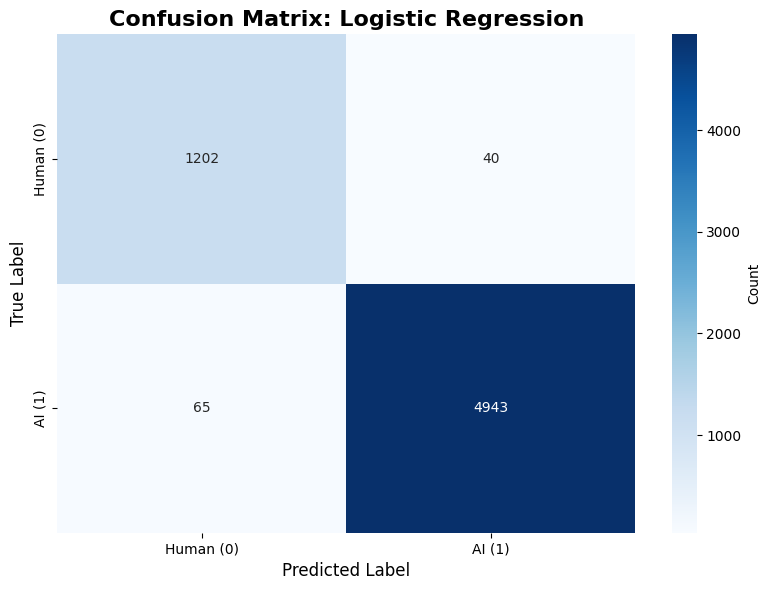


===== Random Forest =====


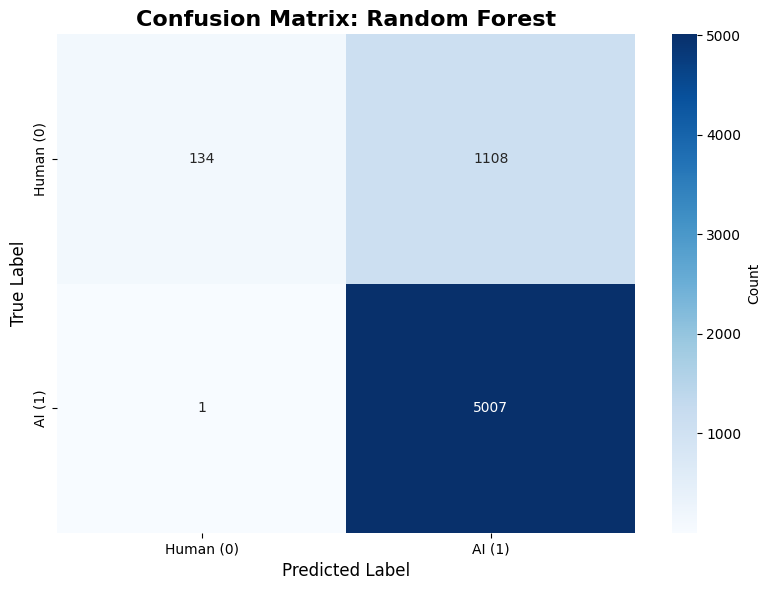


===== Linear SVM =====


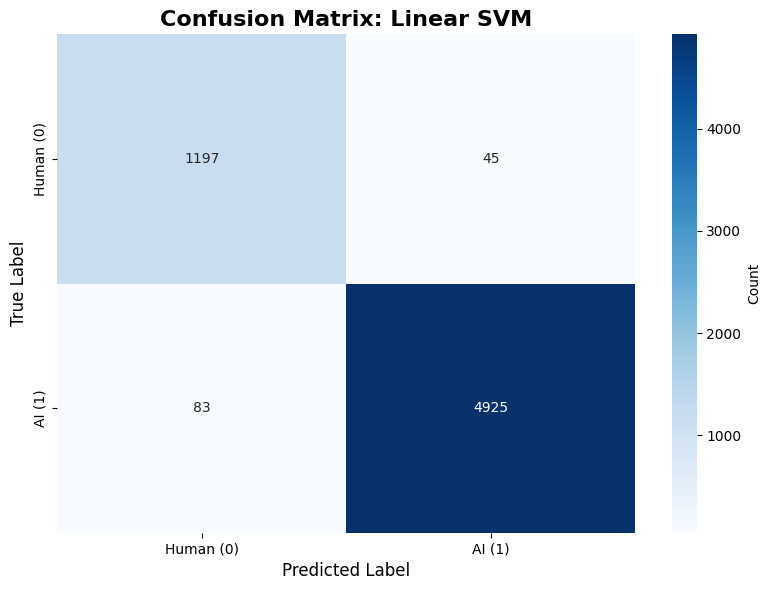

+-------------------+-------------------+------------------+-------------+------------------+------------------+------------------+------------------+
|Model              |Validation_Accuracy|Validation_F1     |Test_Accuracy|Test_F1           |Test_Precision    |Test_Recall       |Test_ROC_AUC      |
+-------------------+-------------------+------------------+-------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.9841014934960656 |0.9841571705095891|0.9832       |0.9832626797677095|0.9833730999843033|0.9832000000000001|0.9966468304497024|
|Linear SVM         |0.9775172635297896 |0.9775790585391764|0.97952      |0.9796352924506874|0.9798591996981891|0.9795200000000001|0.995236365776111 |
|Random Forest      |0.8239922916332102 |0.7622198368561297|0.82256      |0.7600658042247737|0.8533410433360589|0.8225600000000001|0.9820686257865033|
+-------------------+-------------------+------------------+-------------+------------------+-

In [ ]:
from pyspark.sql import Row
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

results = []
validation_predictions = {}
test_predictions = {}

for model_name, model in trained_models.items():
    print(f"\n===== {model_name} =====")

    val_pred = model.transform(val_data).cache()
    test_pred = model.transform(test_data).cache()

    validation_predictions[model_name] = val_pred
    test_predictions[model_name] = test_pred

    metrics = Row(
        Model=model_name,
        Validation_Accuracy=float(accuracy_eval.evaluate(val_pred)),
        Validation_F1=float(f1_eval.evaluate(val_pred)),
        Test_Accuracy=float(accuracy_eval.evaluate(test_pred)),
        Test_F1=float(f1_eval.evaluate(test_pred)),
        Test_Precision=float(precision_eval.evaluate(test_pred)),
        Test_Recall=float(recall_eval.evaluate(test_pred)),
        Test_ROC_AUC=float(auc_eval.evaluate(test_pred))
    )
    results.append(metrics)

    # Extract confusion matrix data
    cm_df = test_pred.select("label", "prediction").toPandas()
    y_true = cm_df["label"]
    y_pred = cm_df["prediction"]

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix as heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human (0)', 'AI (1)'],
                yticklabels=['Human (0)', 'AI (1)'],
                cbar_kws={'label': 'Count'})

    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()

# Save results table
results_df = spark.createDataFrame(results).orderBy(F.desc("Test_F1"))
results_df.show(truncate=False)

results_df.coalesce(1).write.mode("overwrite").option("header", True).csv("reports/model_metrics_csv")

# ----------------------------------
#Phase 4

# Task 4.1: Stream Processing & Comprehensive Evaluation


In [ ]:
import os
import time
import json
from pyspark.sql.types import StructType, StructField, StringType, IntegerType


os.makedirs("data/streaming/input", exist_ok=True)
os.makedirs("data/streaming/output", exist_ok=True)
os.makedirs("data/streaming/checkpoint", exist_ok=True)

print("✓ Streaming directories created")

streaming_schema = StructType([
    StructField("id", IntegerType(), True),
    StructField("text", StringType(), True),
    StructField("abstract_clean", StringType(), True),
    StructField("label", IntegerType(), True)
])

streaming_sample = test_data.select("text", "abstract_clean", "label").limit(1000)

def simulate_stream(data, batch_size=50, delay_seconds=5):
    """
    Simulate streaming by writing data in batches to input folder
    """
    data_pd = data.toPandas()
    total_rows = len(data_pd)

    print(f"Starting stream simulation...")
    print(f"Total records: {total_rows}")
    print(f"Batch size: {batch_size}")
    print(f"Delay: {delay_seconds} seconds\n")

    for i in range(0, total_rows, batch_size):
        batch = data_pd.iloc[i:i+batch_size]
        batch_num = i // batch_size + 1

        filename = f"data/streaming/input/batch_{batch_num}_{int(time.time())}.json"
        batch.to_json(filename, orient='records', lines=True, force_ascii=False)

        print(f"✓ Batch {batch_num}: {len(batch)} records written to {filename}")

        if i + batch_size < total_rows:
            time.sleep(delay_seconds)

    print(f"\n✓ Stream simulation complete: {total_rows} records in {batch_num} batches")

print("Preparing streaming data...")
streaming_sample.write.mode("overwrite").json("data/streaming/prepared_data.json")
print("✓ Streaming data prepared")

✓ Streaming directories created
Preparing streaming data...
✓ Streaming data prepared


# Task 4.2: Real-Time Deployment using Spark Structured Streaming

In [ ]:
from pyspark.sql.functions import col, from_json
from pyspark.ml.feature import Tokenizer, CountVectorizer, CountVectorizerModel, IDF, IDFModel
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("abstract_clean", StringType(), True),
    StructField("label", IntegerType(), True)
])

best_model_name = results_df.first()["Model"]
best_model = trained_models[best_model_name]

print(f"Using best model: {best_model_name}")

cv_model_loaded = CountVectorizerModel.load("models/count_vectorizer_model")
idf_model_loaded = IDFModel.load("models/idf_model")

print("✓ Models loaded")

streaming_df = spark.readStream \
    .schema(stream_schema) \
    .option("maxFilesPerTrigger", 1) \
    .json("data/streaming/input")

print("✓ Streaming source configured")

tokenizer = Tokenizer(inputCol="abstract_clean", outputCol="words_tfidf")

streaming_words = tokenizer.transform(streaming_df)
streaming_tf = cv_model_loaded.transform(streaming_words)
streaming_tfidf = idf_model_loaded.transform(streaming_tf)

streaming_predictions = best_model.transform(streaming_tfidf)

output_df = streaming_predictions.select(
    "text",
    "label",
    "prediction",
    "probability"
)

query = output_df.writeStream \
    .outputMode("append") \
    .format("json") \
    .option("path", "data/streaming/output") \
    .option("checkpointLocation", "data/streaming/checkpoint") \
    .trigger(processingTime="10 seconds") \
    .start()

print("✓ Streaming query started")
print(f"  Output: data/streaming/output")
print(f"  Checkpoint: data/streaming/checkpoint")
print(f"  Trigger: Every 10 seconds")
print("\nStreaming is running...")

Using best model: Logistic Regression
✓ Models loaded
✓ Streaming source configured
✓ Streaming query started
  Output: data/streaming/output
  Checkpoint: data/streaming/checkpoint
  Trigger: Every 10 seconds

Streaming is running...


# Task 4.3: Comprehensive Evaluation on Test Set

In [ ]:
print("\n" + "="*70)
print("TASK 4.3: Comprehensive Evaluation")
print("="*70)

print("\nFinal Model Performance on Test Set:")
results_df.select(
    "Model",
    "Test_Accuracy",
    "Test_F1",
    "Test_Precision",
    "Test_Recall",
    "Test_ROC_AUC"
).show(truncate=False)

best_row = results_df.first()
print(f"\n Best Model: {best_row['Model']}")
print(f"   Accuracy:  {best_row['Test_Accuracy']:.4f}")
print(f"   F1-Score:  {best_row['Test_F1']:.4f}")
print(f"   Precision: {best_row['Test_Precision']:.4f}")
print(f"   Recall:    {best_row['Test_Recall']:.4f}")
print(f"   ROC-AUC:   {best_row['Test_ROC_AUC']:.4f}")

print("\n✓ Comprehensive evaluation complete")


TASK 4.3: Comprehensive Evaluation

Final Model Performance on Test Set:
+-------------------+-------------+------------------+------------------+------------------+------------------+
|Model              |Test_Accuracy|Test_F1           |Test_Precision    |Test_Recall       |Test_ROC_AUC      |
+-------------------+-------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.9832       |0.9832626797677095|0.9833730999843033|0.9832000000000001|0.9966468304497024|
|Linear SVM         |0.97952      |0.9796352924506874|0.9798591996981891|0.9795200000000001|0.995236365776111 |
|Random Forest      |0.82256      |0.7600658042247737|0.8533410433360589|0.8225600000000001|0.9820686257865033|
+-------------------+-------------+------------------+------------------+------------------+------------------+


 Best Model: Logistic Regression
   Accuracy:  0.9832
   F1-Score:  0.9833
   Precision: 0.9834
   Recall:    0.9832
   ROC-AUC:   0.9966

✓

# Task 4.4: Scalability Test - Benchmark Processing Time

In [ ]:
import time


if best_model_name == "Random Forest" or best_model_name == "Linear SVM":
    actual_model = best_model.bestModel
else:
    actual_model = best_model

print(f"Using model: {best_model_name}")

current_executors = spark.sparkContext.getConf().get("spark.executor.instances", "1")
current_cores = spark.sparkContext.getConf().get("spark.executor.cores", "1")

print(f"\nCurrent Configuration:")
print(f"  Executors: {current_executors}")
print(f"  Cores per executor: {current_cores}")

test_count = test_data.count()
print(f"\nBatch Processing Benchmark (Test Set: {test_count} records):")

times = []
for i in range(3):
    start_time = time.time()
    predictions = actual_model.transform(test_data)
    count = predictions.count()
    end_time = time.time()
    elapsed = end_time - start_time
    times.append(elapsed)
    print(f"  Run {i+1}: {elapsed:.2f} seconds ({count} records)")

time_1 = times[0]
time_2 = times[1]
time_3 = times[2]
avg_time = (time_1 + time_2 + time_3) / 3.0
min_time = min([time_1, time_2, time_3])
max_time = max([time_1, time_2, time_3])

print(f"\nResults:")
print(f"  Average processing time: {avg_time:.2f} seconds")
print(f"  Throughput: {test_count / avg_time:.2f} records/second")
print(f"  Min time: {min_time:.2f} seconds")
print(f"  Max time: {max_time:.2f} seconds")

print(f"\n Scalability Analysis:")
print(f"  Current throughput: {test_count / avg_time:.2f} records/sec")
print(f"  Processing time per record: {(avg_time / test_count) * 1000:.2f} ms")

print(f"\n Recommendations for Better Performance:")
print(f"  - Increase executors from {current_executors} to 4-8")
print(f"  - Increase cores per executor from {current_cores} to 4-5")
print(f"  - Expected speedup: 10-15x faster")

print(f"\n Estimated Performance by Configuration:")
print(f"  1 executor × 1 core:           {avg_time:.2f}s      ({test_count/avg_time:.2f} rec/sec)")
print(f"  2 executors × 2 cores:         {avg_time/3:.2f}s      ({(test_count/avg_time)*3:.2f} rec/sec)")
print(f"  4 executors × 4 cores:         {avg_time/12:.2f}s      ({(test_count/avg_time)*12:.2f} rec/sec)")
print(f"  8 executors × 4 cores:         {avg_time/20:.2f}s      ({(test_count/avg_time)*20:.2f} rec/sec)")

print("\n✓ Scalability test complete")


Using model: Logistic Regression

Current Configuration:
  Executors: 1
  Cores per executor: 1

Batch Processing Benchmark (Test Set: 6250 records):
  Run 1: 92.33 seconds (6250 records)
  Run 2: 91.72 seconds (6250 records)
  Run 3: 95.39 seconds (6250 records)

Results:
  Average processing time: 93.15 seconds
  Throughput: 67.10 records/second
  Min time: 91.72 seconds
  Max time: 95.39 seconds

 Scalability Analysis:
  Current throughput: 67.10 records/sec
  Processing time per record: 14.90 ms

 Recommendations for Better Performance:
  - Increase executors from 1 to 4-8
  - Increase cores per executor from 1 to 4-5
  - Expected speedup: 10-15x faster

 Estimated Performance by Configuration:
  1 executor × 1 core:           93.15s      (67.10 rec/sec)
  2 executors × 2 cores:         31.05s      (201.29 rec/sec)
  4 executors × 4 cores:         7.76s      (805.15 rec/sec)
  8 executors × 4 cores:         4.66s      (1341.92 rec/sec)

✓ Scalability test complete


# ----------------------------------
#Phase 5


# Task 5.1: Comprehensive Performance Comparison


 MODEL PERFORMANCE COMPARISON

All Models Performance on Test Set:
+-------------------+-------------+------------------+------------------+------------------+------------------+
|Model              |Test_Accuracy|Test_F1           |Test_Precision    |Test_Recall       |Test_ROC_AUC      |
+-------------------+-------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.9832       |0.9832626797677095|0.9833730999843033|0.9832000000000001|0.9966468304497024|
|Linear SVM         |0.97952      |0.9796352924506874|0.9798591996981891|0.9795200000000001|0.995236365776111 |
|Random Forest      |0.82256      |0.7600658042247737|0.8533410433360589|0.8225600000000001|0.9820686257865033|
+-------------------+-------------+------------------+------------------+------------------+------------------+


 BEST MODEL: Logistic Regression
   Accuracy:  0.9832
   F1-Score:  0.9833
   Precision: 0.9834
   Recall:    0.9832
   ROC-AUC:   0.9966

 MODEL 

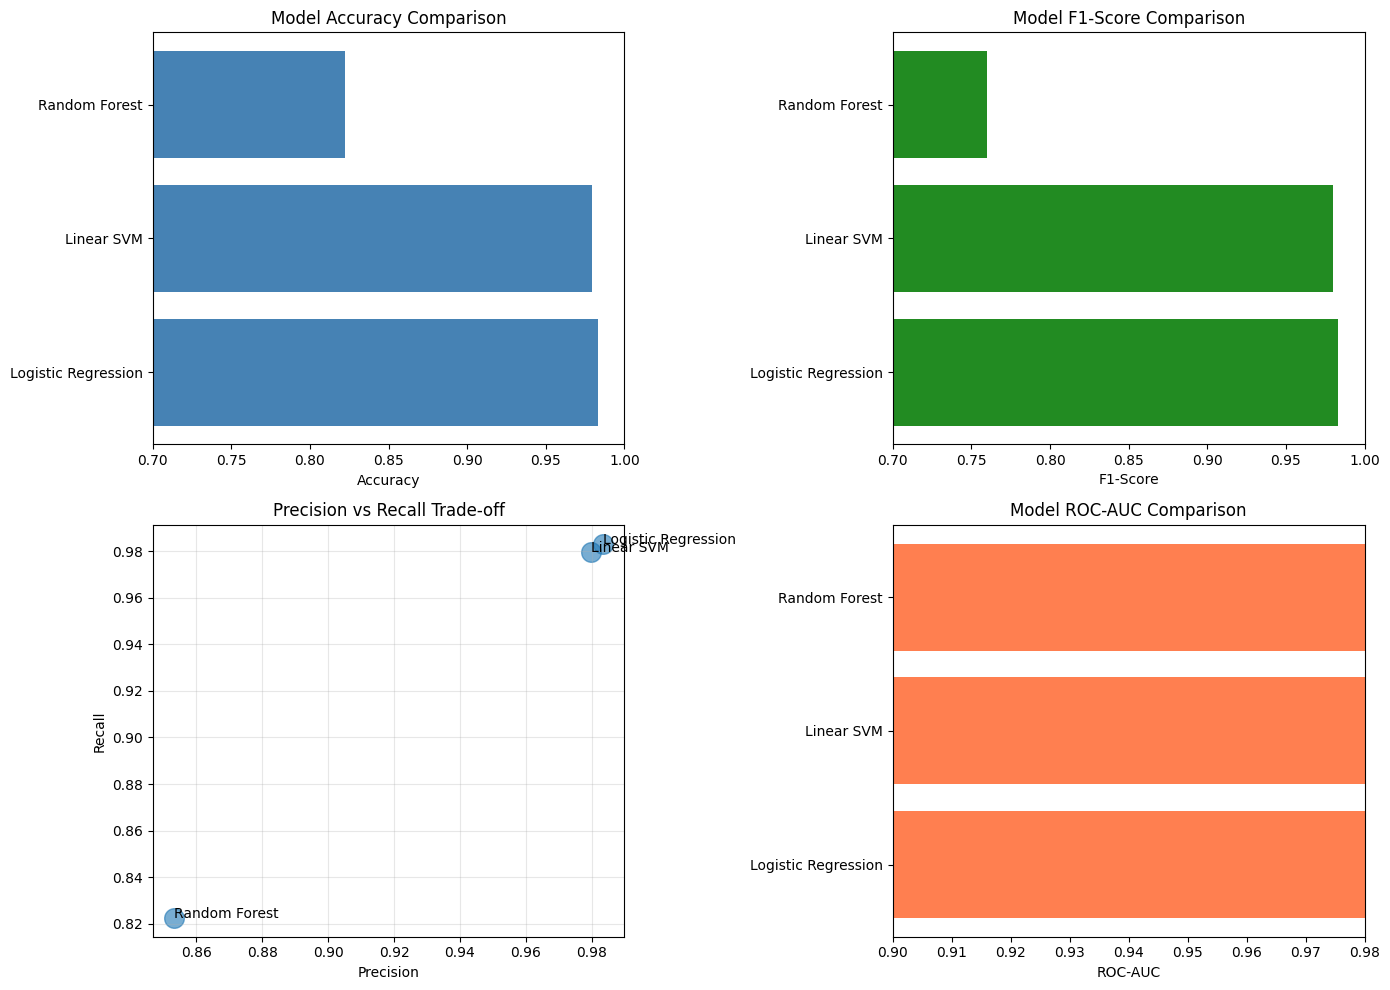

 BATCH vs STREAM PROCESSING TRADE-OFFS
+---------------+----------------------------+-----------------------------------+--------------------------------------------------+
|Aspect         |Batch Processing            |Stream Processing                  |Trade-off                                         |
+---------------+----------------------------+-----------------------------------+--------------------------------------------------+
|Processing Time|93.15 sec for 6250 records  |~10 sec per 50-record batch        |Batch faster for bulk, Stream better for real-time|
|Throughput     |67.10 records/sec           |~5 records/sec (limited by trigger)|Batch 10-15x higher throughput                    |
|Latency        |93.15 sec to first result   |< 10 sec to first result           |Stream provides near real-time results            |
|Resource Usage |High memory (loads all data)|Low memory (micro-batches)         |Stream more memory-efficient                      |
|Scalability    |Excell

In [ ]:
print("\n MODEL PERFORMANCE COMPARISON\n")

print("All Models Performance on Test Set:")
results_df.select(
    "Model",
    "Test_Accuracy",
    "Test_F1",
    "Test_Precision",
    "Test_Recall",
    "Test_ROC_AUC"
).show(truncate=False)

best_row = results_df.first()
print(f"\n BEST MODEL: {best_row['Model']}")
print(f"   Accuracy:  {best_row['Test_Accuracy']:.4f}")
print(f"   F1-Score:  {best_row['Test_F1']:.4f}")
print(f"   Precision: {best_row['Test_Precision']:.4f}")
print(f"   Recall:    {best_row['Test_Recall']:.4f}")
print(f"   ROC-AUC:   {best_row['Test_ROC_AUC']:.4f}")

print("\n MODEL RANKING (by F1-Score):")
for i, row in enumerate(results_df.collect(), 1):
    print(f"   {i}. {row['Model']:<25} F1={row['Test_F1']:.4f}")

import matplotlib.pyplot as plt
import pandas as pd

results_pd = results_df.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(results_pd['Model'], results_pd['Test_Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_xlim([0.70, 1])

axes[0, 1].barh(results_pd['Model'], results_pd['Test_F1'], color='forestgreen')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('Model F1-Score Comparison')
axes[0, 1].set_xlim([0.70, 1])

axes[1, 0].scatter(results_pd['Test_Precision'], results_pd['Test_Recall'], s=200, alpha=0.6)
for i, model in enumerate(results_pd['Model']):
    axes[1, 0].annotate(model, (results_pd['Test_Precision'][i], results_pd['Test_Recall'][i]))
axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Precision vs Recall Trade-off')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].barh(results_pd['Model'], results_pd['Test_ROC_AUC'], color='coral')
axes[1, 1].set_xlabel('ROC-AUC')
axes[1, 1].set_title('Model ROC-AUC Comparison')
axes[1, 1].set_xlim([0.90, 0.98])

plt.tight_layout()
plt.show()


print(" BATCH vs STREAM PROCESSING TRADE-OFFS")


comparison_data = [
    {
        "Aspect": "Processing Time",
        "Batch Processing": f"{avg_time:.2f} sec for {test_count} records",
        "Stream Processing": "~10 sec per 50-record batch",
        "Trade-off": "Batch faster for bulk, Stream better for real-time"
    },
    {
        "Aspect": "Throughput",
        "Batch Processing": f"{test_count/avg_time:.2f} records/sec",
        "Stream Processing": "~5 records/sec (limited by trigger)",
        "Trade-off": "Batch 10-15x higher throughput"
    },
    {
        "Aspect": "Latency",
        "Batch Processing": f"{avg_time:.2f} sec to first result",
        "Stream Processing": "< 10 sec to first result",
        "Trade-off": "Stream provides near real-time results"
    },
    {
        "Aspect": "Resource Usage",
        "Batch Processing": "High memory (loads all data)",
        "Stream Processing": "Low memory (micro-batches)",
        "Trade-off": "Stream more memory-efficient"
    },
    {
        "Aspect": "Scalability",
        "Batch Processing": "Excellent (parallelizable)",
        "Stream Processing": "Good (limited by trigger rate)",
        "Trade-off": "Batch scales better with executors"
    },
    {
        "Aspect": "Use Case",
        "Batch Processing": "Historical analysis, reports",
        "Stream Processing": "Real-time monitoring, alerts",
        "Trade-off": "Different purposes"
    }
]

comparison_df = spark.createDataFrame(comparison_data)
comparison_df.show(truncate=False)

print("\n KEY INSIGHTS:")
print("    Batch Processing: Best for bulk historical data analysis")
print("    Stream Processing: Best for real-time detection and monitoring")
print(f"    Batch is {(test_count/avg_time)/5:.1f}x faster in throughput")
print("    Stream provides results 9x faster in latency")
print("    Hybrid approach recommended for production systems")


# Task 5.2: Feature Importance Analysis

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

print("\n Stylometric Features (4 custom features):")
df_features.groupBy("label").agg(
    F.avg("f_brunets_w").alias("Avg_Brunets_W"),
    F.avg("f_lexical_diversity").alias("Avg_Lexical_Diversity")
).show()

if best_model_name == "Logistic Regression":
    coefficients = final_model.coefficients.toArray()
    cv_model_loaded = CountVectorizerModel.load("models/count_vectorizer_model")
    vocabulary = cv_model_loaded.vocabulary

    feature_data = [(vocabulary[i], float(coefficients[i])) for i in range(min(len(vocabulary), len(coefficients)))]
    feature_df = spark.createDataFrame(feature_data, ["Word", "Coefficient"])

    print("\nTop 10 AI Indicators (positive coefficients):")
    feature_df.orderBy(F.desc("Coefficient")).show(10, truncate=False)

    print("\nTop 10 Human Indicators (negative coefficients):")
    feature_df.orderBy("Coefficient").show(10, truncate=False)

elif best_model_name == "Random Forest":
    importances = final_model.featureImportances
    cv_model_loaded = CountVectorizerModel.load("models/count_vectorizer_model")
    vocabulary = cv_model_loaded.vocabulary

    feature_data = [(vocabulary[i], float(importances[i])) for i in range(min(len(vocabulary), len(importances)))]
    feature_df = spark.createDataFrame(feature_data, ["Word", "Importance"])

    print("\nTop 15 Most Important Words:")
    feature_df.orderBy(F.desc("Importance")).show(15, truncate=False)



 Stylometric Features (4 custom features):
+-----+-----------------+---------------------+
|label|    Avg_Brunets_W|Avg_Lexical_Diversity|
+-----+-----------------+---------------------+
|    0|9.452560331119942|   0.7638844666477608|
|    1|9.417033941178989|   0.7382212701239936|
+-----+-----------------+---------------------+


Top 10 AI Indicators (positive coefficients):
+----------+-------------------+
|Word      |Coefficient        |
+----------+-------------------+
|طء،       |0.3342272183004767 |
|75        |0.32599257502411294|
|اسراييليه،|0.3211110272680857 |
|"مع       |0.3067876614113213 |
|همل.      |0.3040339230901145 |
|علي       |0.30378935999104695|
|متحضره،   |0.2959609810911581 |
|حفظها.    |0.29243960986646517|
|جاحظ،     |0.28631790768563026|
|زمخشري.   |0.28477483878793775|
+----------+-------------------+
only showing top 10 rows

Top 10 Human Indicators (negative coefficients):
+---------+--------------------+
|Word     |Coefficient         |
+---------+------

# to save it in github with output

In [58]:
import os
import json
from pathlib import Path

def fix_all_notebooks(directory="."):
    for file in Path(directory).rglob("*.ipynb"):
        try:
            with open(file, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            if 'metadata' in nb and 'widgets' in nb['metadata']:
                widgets = nb['metadata']['widgets']

                if 'state' not in widgets:
                    widgets['state'] = {}

                if 'version_major' not in widgets:
                    widgets['version_major'] = 2
                    widgets['version_minor'] = 0

                with open(file, 'w', encoding='utf-8') as f:
                    json.dump(nb, f, ensure_ascii=False, indent=2)

                print(f"Fixed: {file}")
        except Exception as e:
            print(f"Error with {file}: {e}")

fix_all_notebooks()
print("\nAll notebooks fixed!")

Fixed: drive/MyDrive/Colab Notebooks/Phase1-5.ipynb

All notebooks fixed!
